<style>
body {
    font-family: Arial, sans-serif;
}

h1 {
    color: white;
    background-color: #2E86C1;
    padding: 10px;
    border-radius: 8px;
}

h2 {
    color: #1B4F72;
    border-bottom: 2px solid #2E86C1;
}

h3 {
    color: #117A65;
}

.box {
    background-color: #EBF5FB;
    padding: 10px;
    border-left: 5px solid #2E86C1;
    border-radius: 5px;
}
<h1 style="color:#2E86C1;text-align:center;">Exploratory Data Analysis and Addiction Prediction using Python</h1>
<h3 style="text-align:center;">Course 602 – Data Analytics using Python</h3>
<h4 style="text-align:center;">Dataset: Smartphone Addiction Dataset</h4>
<h2 style="color:#117A65;">Step 1: Installing Required Libraries</h2>
<p>We install necessary Python libraries for data analysis, visualization and machine learning.</p>
</style>

Inporting all the Required Libraries.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import linear_model
from sklearn.linear_model import LinearRegression


TASK 1: Data Understanding

Loading the Dataset Using Pandas

In [2]:
df = pd.read_csv("Smartphone.csv")
df.head()


,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


Displaying First 5 Rows Using Head.

In [3]:
df.head()


,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


Displaying Last 5 Rows Using Tail.

In [4]:
df.tail()


,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
7495,TXN07496,U07496,26,Other,9.85,1.75,3.13,3.49,5.81,249,122,11.99,Low,Yes,Moderate,1
7496,TXN07497,U07497,35,Male,5.67,2.33,2.76,5.90,8.47,197,56,7.08,Low,No,NaN,0
7497,TXN07498,U07498,22,Female,9.99,3.61,1.09,1.16,8.17,207,24,12.84,Medium,Yes,Severe,1
7498,TXN07499,U07499,23,Male,8.74,1.59,0.07,4.64,6.19,134,62,10.52,High,Yes,Severe,1
7499,TXN07500,U07500,27,Female,10.04,5.40,0.73,5.45,5.58,215,38,12.17,Low,Yes,Severe,1


Dataset Shape

In [5]:
df.shape


(7500, 16)

All The Column Names From The Dataset Named Smartphone.csv

In [6]:
df.columns


Index(['transaction_id', 'user_id', 'age', 'gender', 'daily_screen_time_hours',
       'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours',
       'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time',
       'stress_level', 'academic_work_impact', 'addiction_level',
       'addicted_label'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   object 
 1   user_id                  7500 non-null   object 
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   object 
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   object 
 13  academic_work_impact     7500 non-null   object 
 14  addiction_level         

Identify Qualitative Data (Discrete & Continuous)

Numerical Data

In [8]:

quantitative_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("Quantitative Columns:")
print(quantitative_cols)

Quantitative Columns:
Index(['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours',
       'work_study_hours', 'sleep_hours', 'notifications_per_day',
       'app_opens_per_day', 'weekend_screen_time', 'addicted_label'],
      dtype='object')


Discrete & Continuous

In [9]:
discrete_cols = []
continuous_cols = []

for col in quantitative_cols:
    unique_values = df[col].nunique()
    
    # Rule: if unique values are small → discrete
    if unique_values < 20:
        discrete_cols.append(col)
    else:
        continuous_cols.append(col)

print("\nDiscrete Data Columns:")
print(discrete_cols)

print("\nContinuous Data Columns:")
print(continuous_cols)


Discrete Data Columns:
['age', 'addicted_label']

Continuous Data Columns:
['daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time']


Identify Qualitative Data (Nominal & Ordinal)

Categorical Columns


In [10]:
qualitative_cols = df.select_dtypes(include=['object']).columns

print("Qualitative Columns:")
print(qualitative_cols)

Qualitative Columns:
Index(['transaction_id', 'user_id', 'gender', 'stress_level',
       'academic_work_impact', 'addiction_level'],
      dtype='object')


Nominal vs Ordinal

In [11]:
nominal_cols = []
ordinal_cols = []

# Example ordinal patterns (customize based on dataset)
ordinal_keywords = [
    ['low', 'medium', 'high'],
    ['poor', 'average', 'good', 'excellent'],
    ['small', 'medium', 'large']
]

for col in qualitative_cols:
    values = df[col].dropna().unique()
    values_lower = [str(v).lower() for v in values]

    is_ordinal = False
    
    for pattern in ordinal_keywords:
        if all(val in pattern for val in values_lower):
            is_ordinal = True
            break
    
    if is_ordinal:
        ordinal_cols.append(col)
    else:
        nominal_cols.append(col)

print("\nNominal Data Columns:")
print(nominal_cols)

print("\nOrdinal Data Columns:")
print(ordinal_cols)


Nominal Data Columns:
['transaction_id', 'user_id', 'gender', 'academic_work_impact', 'addiction_level']

Ordinal Data Columns:
['stress_level']


TASK 2: EDA

1. Univariate Analysis

a. Histogram

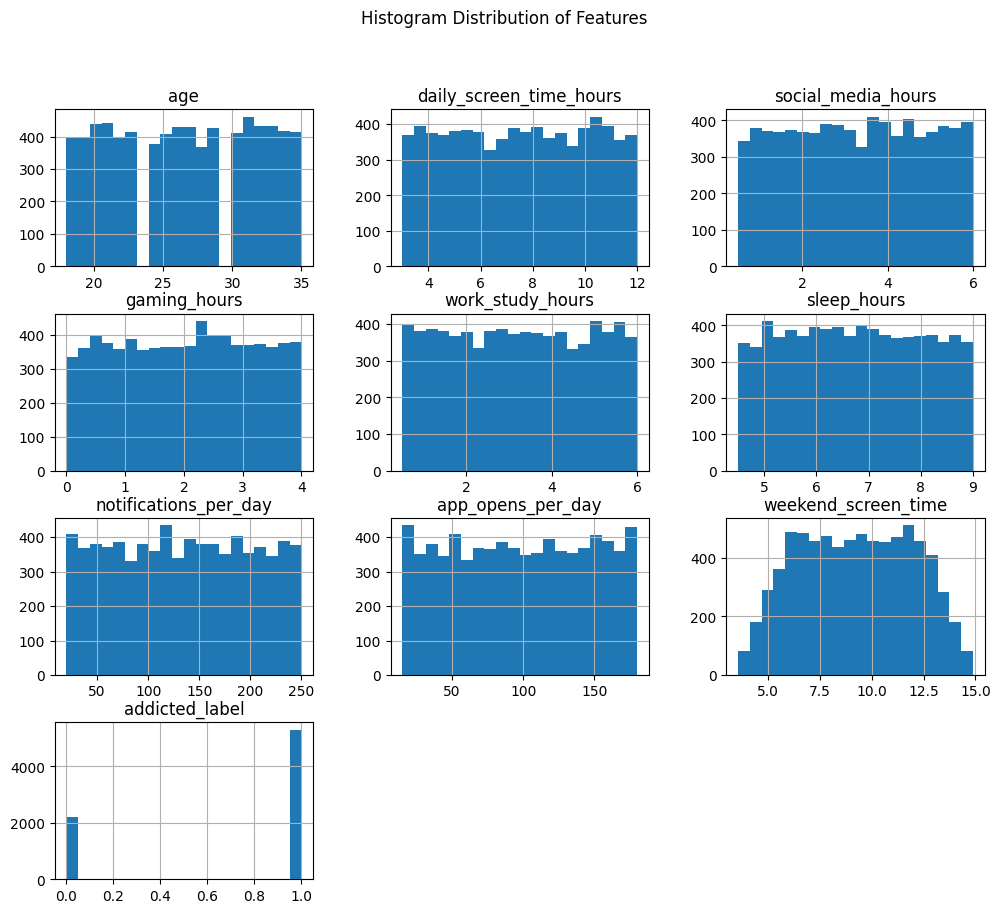

In [12]:
df.hist(figsize=(12,10), bins=20)

plt.suptitle("Histogram Distribution of Features")
plt.show()

b. Boxplot

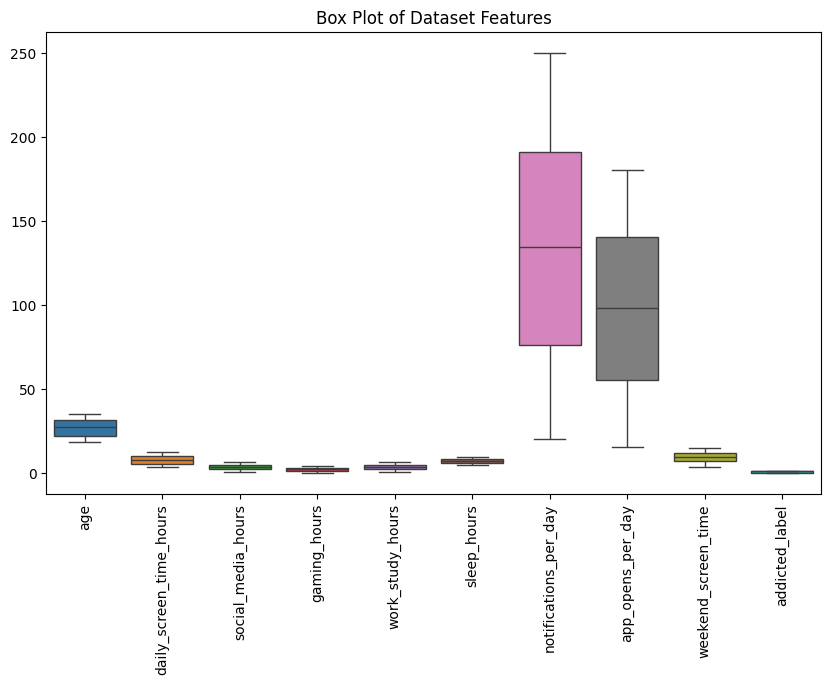

In [13]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df)

plt.title("Box Plot of Dataset Features")
plt.xticks(rotation=90)

plt.show()

2. Bivariant

b. Scatterplot 

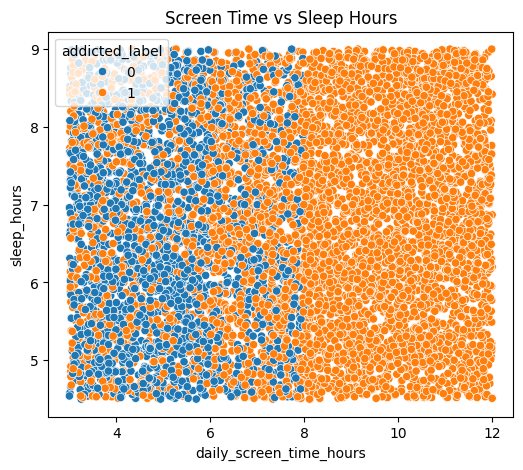

In [14]:
plt.figure(figsize=(6,5))

sns.scatterplot(
    x='daily_screen_time_hours',
    y='sleep_hours',
    hue='addicted_label',
    data=df
)

plt.title("Screen Time vs Sleep Hours")
plt.show()

Multivariant


a. Heatmap


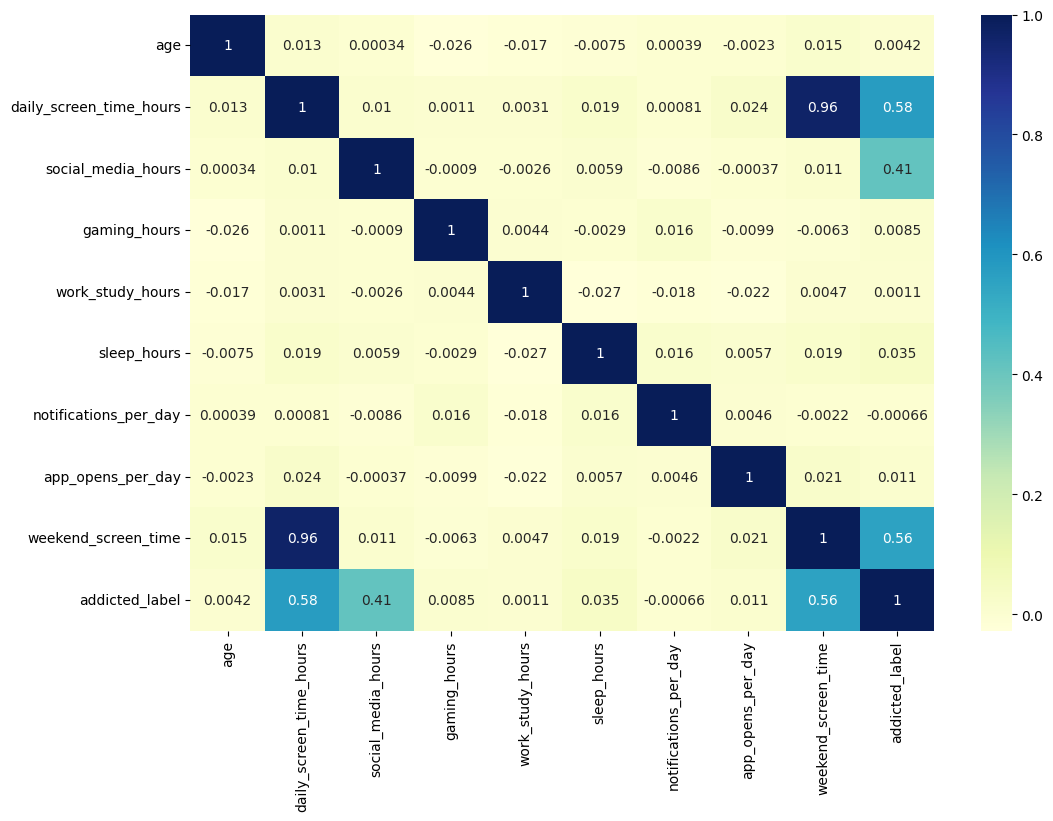

In [15]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="YlGnBu")
plt.show()

b. Pairplot

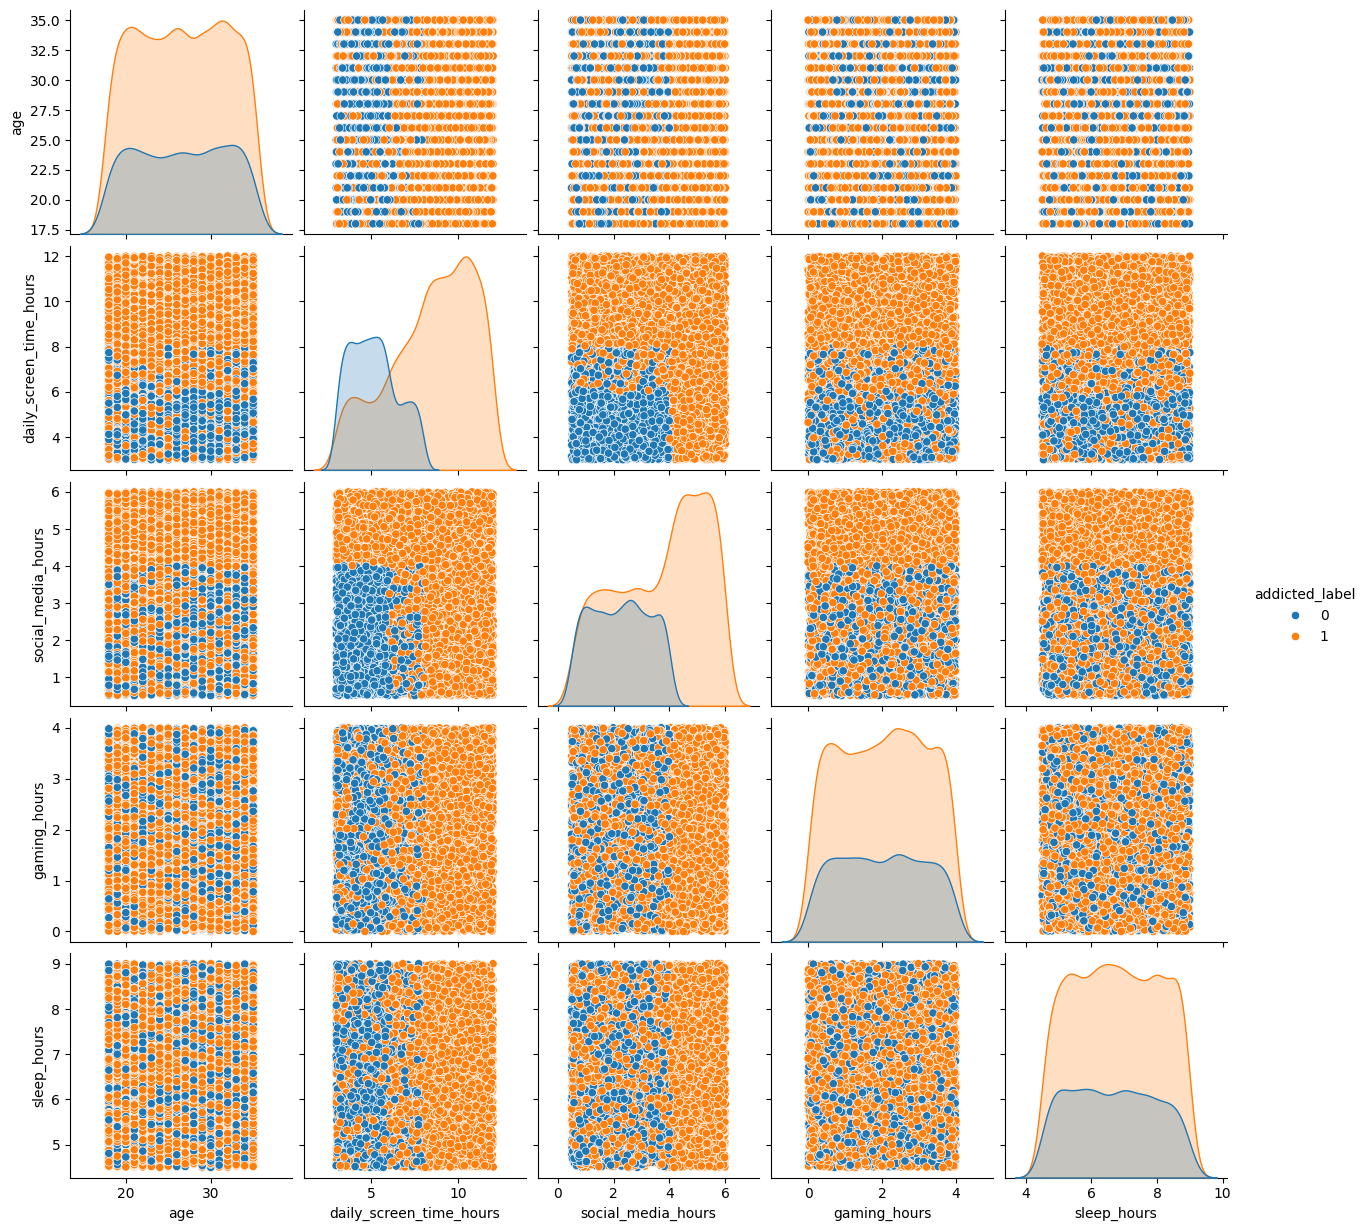

In [16]:
sns.pairplot(
    df,
    vars=['age','daily_screen_time_hours','social_media_hours','gaming_hours','sleep_hours',],
    hue='addicted_label'
)

plt.show()

Task 3:Missing Values & Outliers


In [17]:
df.isnull().sum()

transaction_id               0
user_id                      0
age                          0
gender                       0
daily_screen_time_hours      0
social_media_hours           0
gaming_hours                 0
work_study_hours             0
sleep_hours                  0
notifications_per_day        0
app_opens_per_day            0
weekend_screen_time          0
stress_level                 0
academic_work_impact         0
addiction_level            819
addicted_label               0
dtype: int64

Handling the Misssing Addiction Values Using Mode


In [18]:
df['addiction_level'] = df['addiction_level'].fillna(df['addiction_level'].mode()[0])

Checking the Misssing Values

In [19]:
df.isnull().sum()

transaction_id             0
user_id                    0
age                        0
gender                     0
daily_screen_time_hours    0
social_media_hours         0
gaming_hours               0
work_study_hours           0
sleep_hours                0
notifications_per_day      0
app_opens_per_day          0
weekend_screen_time        0
stress_level               0
academic_work_impact       0
addiction_level            0
addicted_label             0
dtype: int64

Detecting the Outliers Using Boxplot

In [20]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("Numerical Columns:")
print(numeric_cols)

Numerical Columns:
Index(['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours',
       'work_study_hours', 'sleep_hours', 'notifications_per_day',
       'app_opens_per_day', 'weekend_screen_time', 'addicted_label'],
      dtype='object')


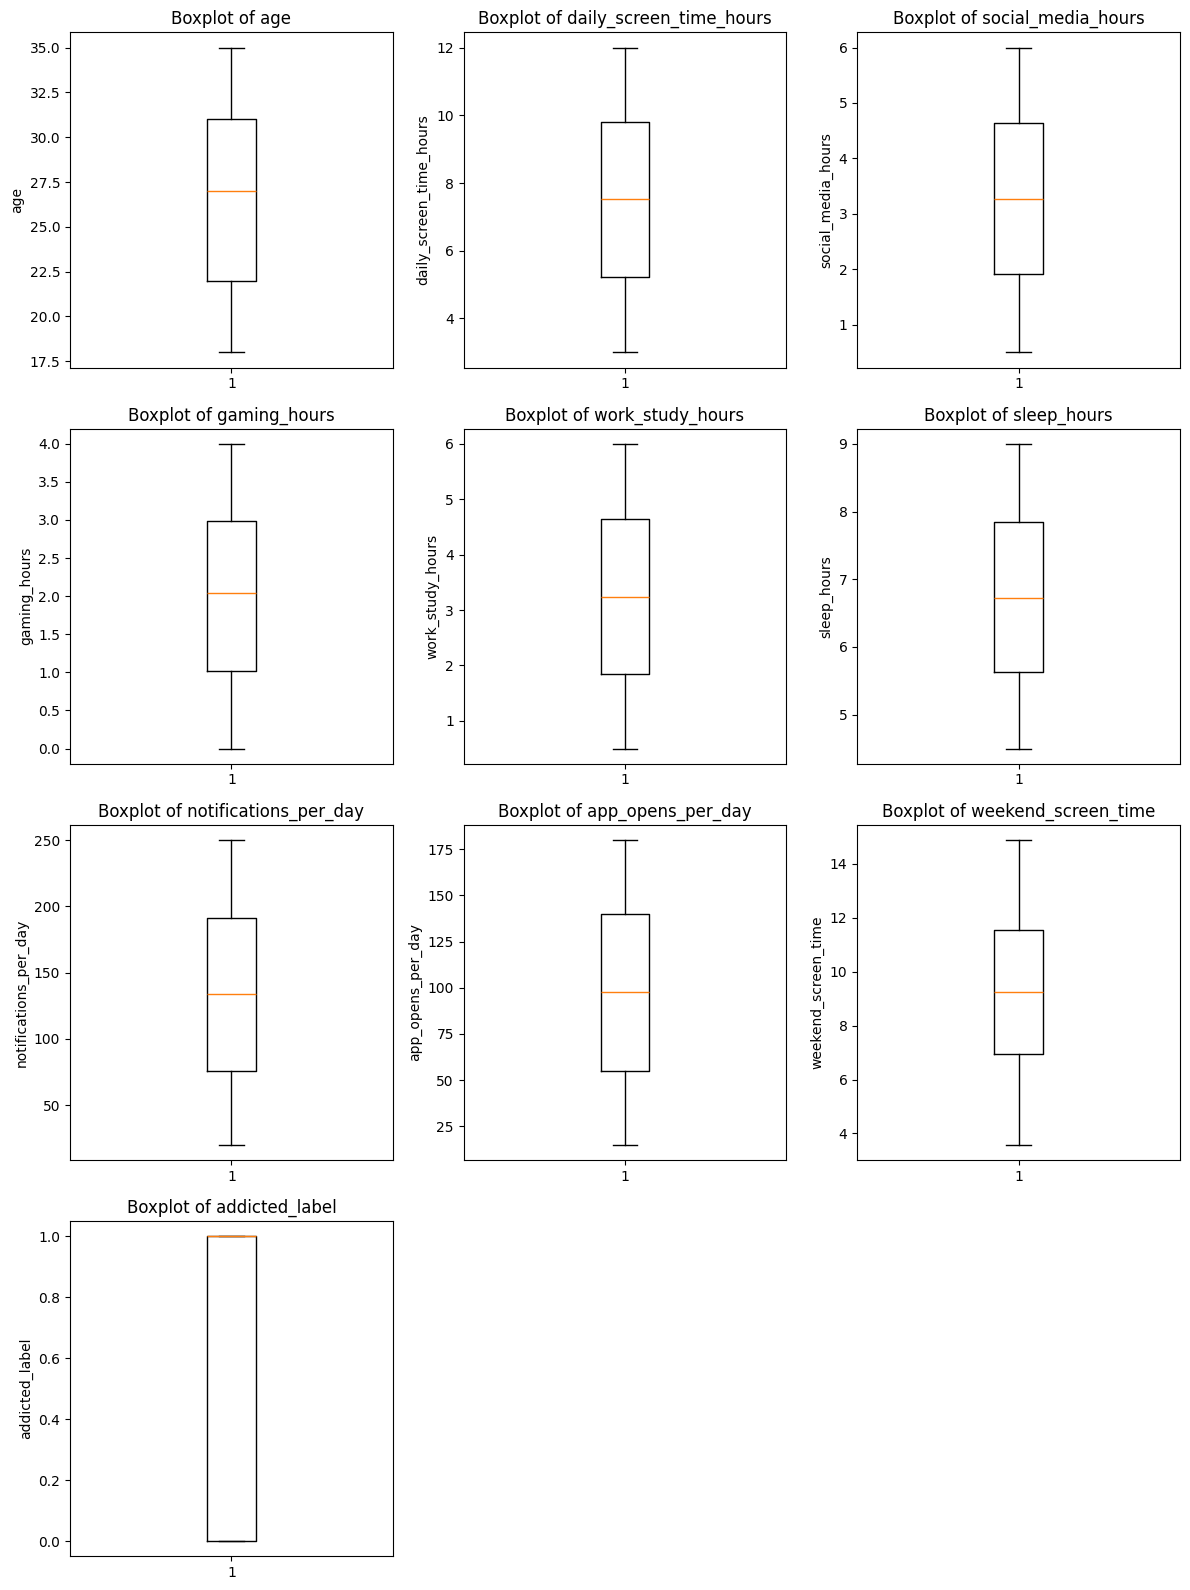

In [21]:
import math

num_cols = len(numeric_cols)
nrows = math.ceil(num_cols / 3)

fig, axes = plt.subplots(nrows, 3, figsize=(12, 4*nrows))

for i, col in enumerate(numeric_cols):
    ax = axes.flat[i]
    ax.boxplot(df[col])
    ax.set_title(f"Boxplot of {col}")
    ax.set_ylabel(col)

# Hide empty subplots
for i in range(num_cols, nrows * 3):
    axes.flat[i].set_visible(False)

plt.tight_layout()
plt.show()

In [22]:
df_removed = df.copy()

for col in numeric_cols:
    Q1 = df_removed[col].quantile(0.25)
    Q3 = df_removed[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df_removed = df_removed[
        (df_removed[col] >= lower_bound) & 
        (df_removed[col] <= upper_bound)
    ]

print("Shape after removing outliers:", df_removed.shape)

Shape after removing outliers: (7500, 16)


In [23]:
df_capped = df.copy()

for col in numeric_cols:
    Q1 = df_capped[col].quantile(0.25)
    Q3 = df_capped[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df_capped[col] = np.where(df_capped[col] < lower_bound, lower_bound, df_capped[col])
    df_capped[col] = np.where(df_capped[col] > upper_bound, upper_bound, df_capped[col])

print("Outliers capped successfully!")

Outliers capped successfully!


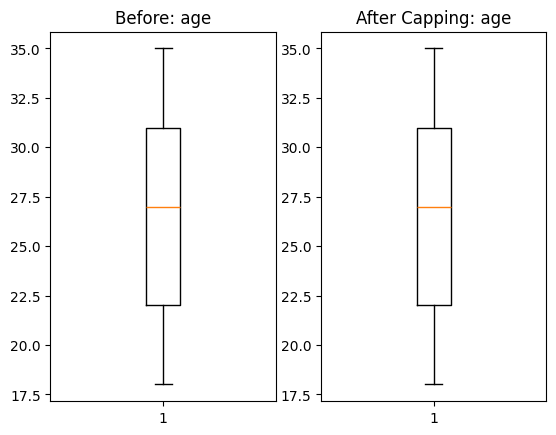

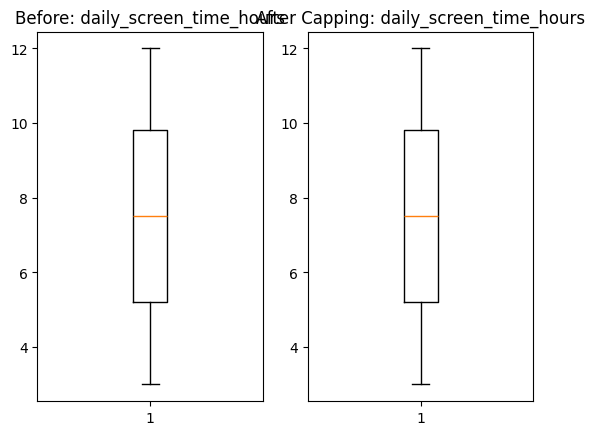

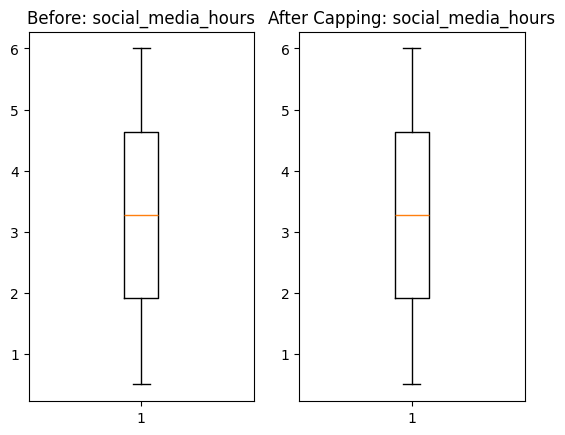

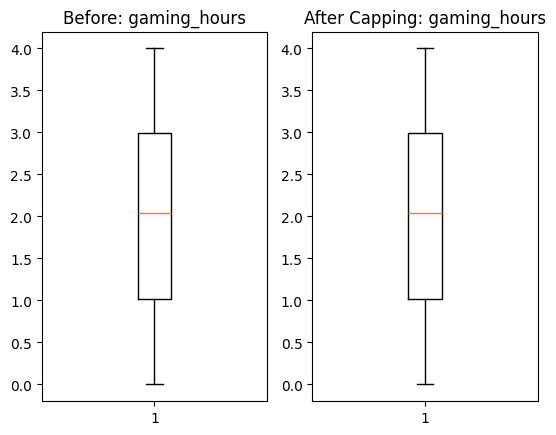

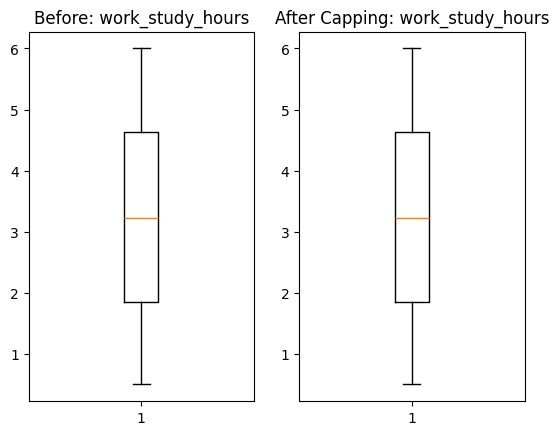

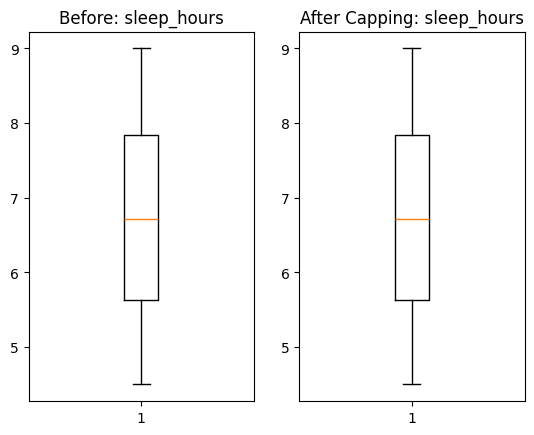

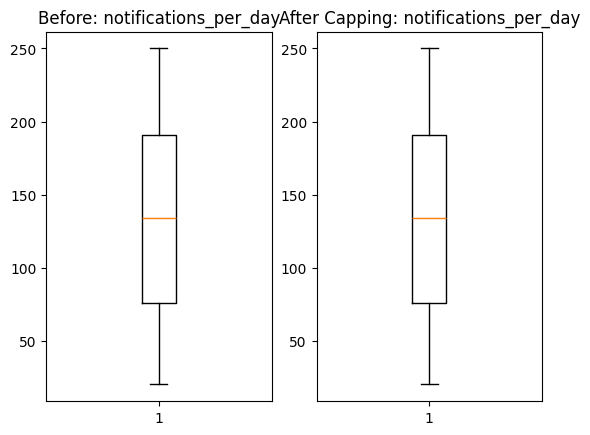

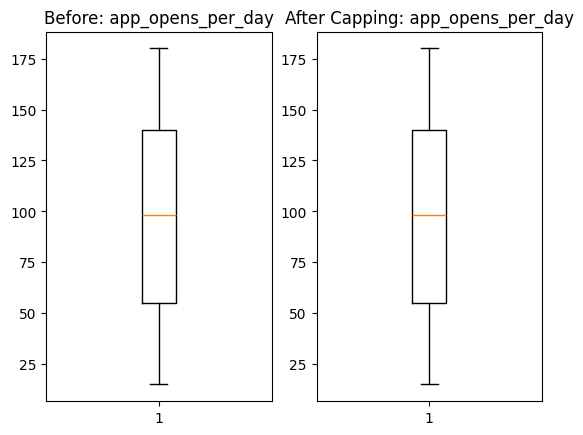

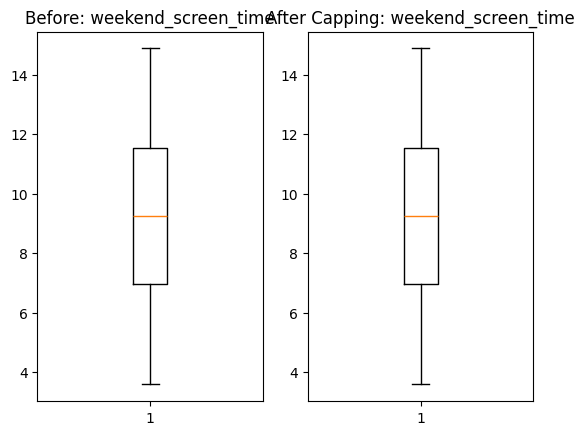

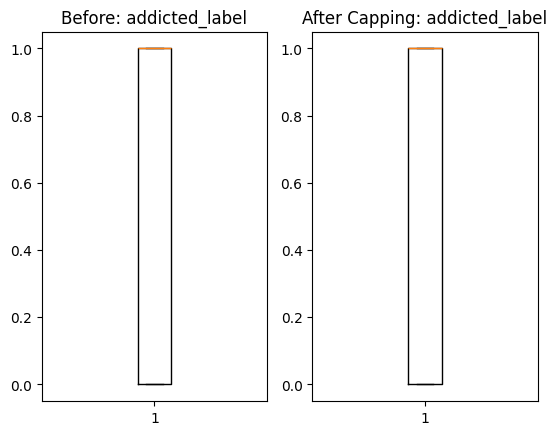

In [24]:
for col in numeric_cols:
    plt.figure()
    
    plt.subplot(1,2,1)
    plt.boxplot(df[col])
    plt.title(f"Before: {col}")
    
    plt.subplot(1,2,2)
    plt.boxplot(df_capped[col])
    plt.title(f"After Capping: {col}")
    
    plt.show()

 Task 4: Spread of Data

A. Checking the Data Distribution

Normal Data Distribution

In [25]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("Numerical Columns:")
print(numeric_cols)

Numerical Columns:
Index(['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours',
       'work_study_hours', 'sleep_hours', 'notifications_per_day',
       'app_opens_per_day', 'weekend_screen_time', 'addicted_label'],
      dtype='object')


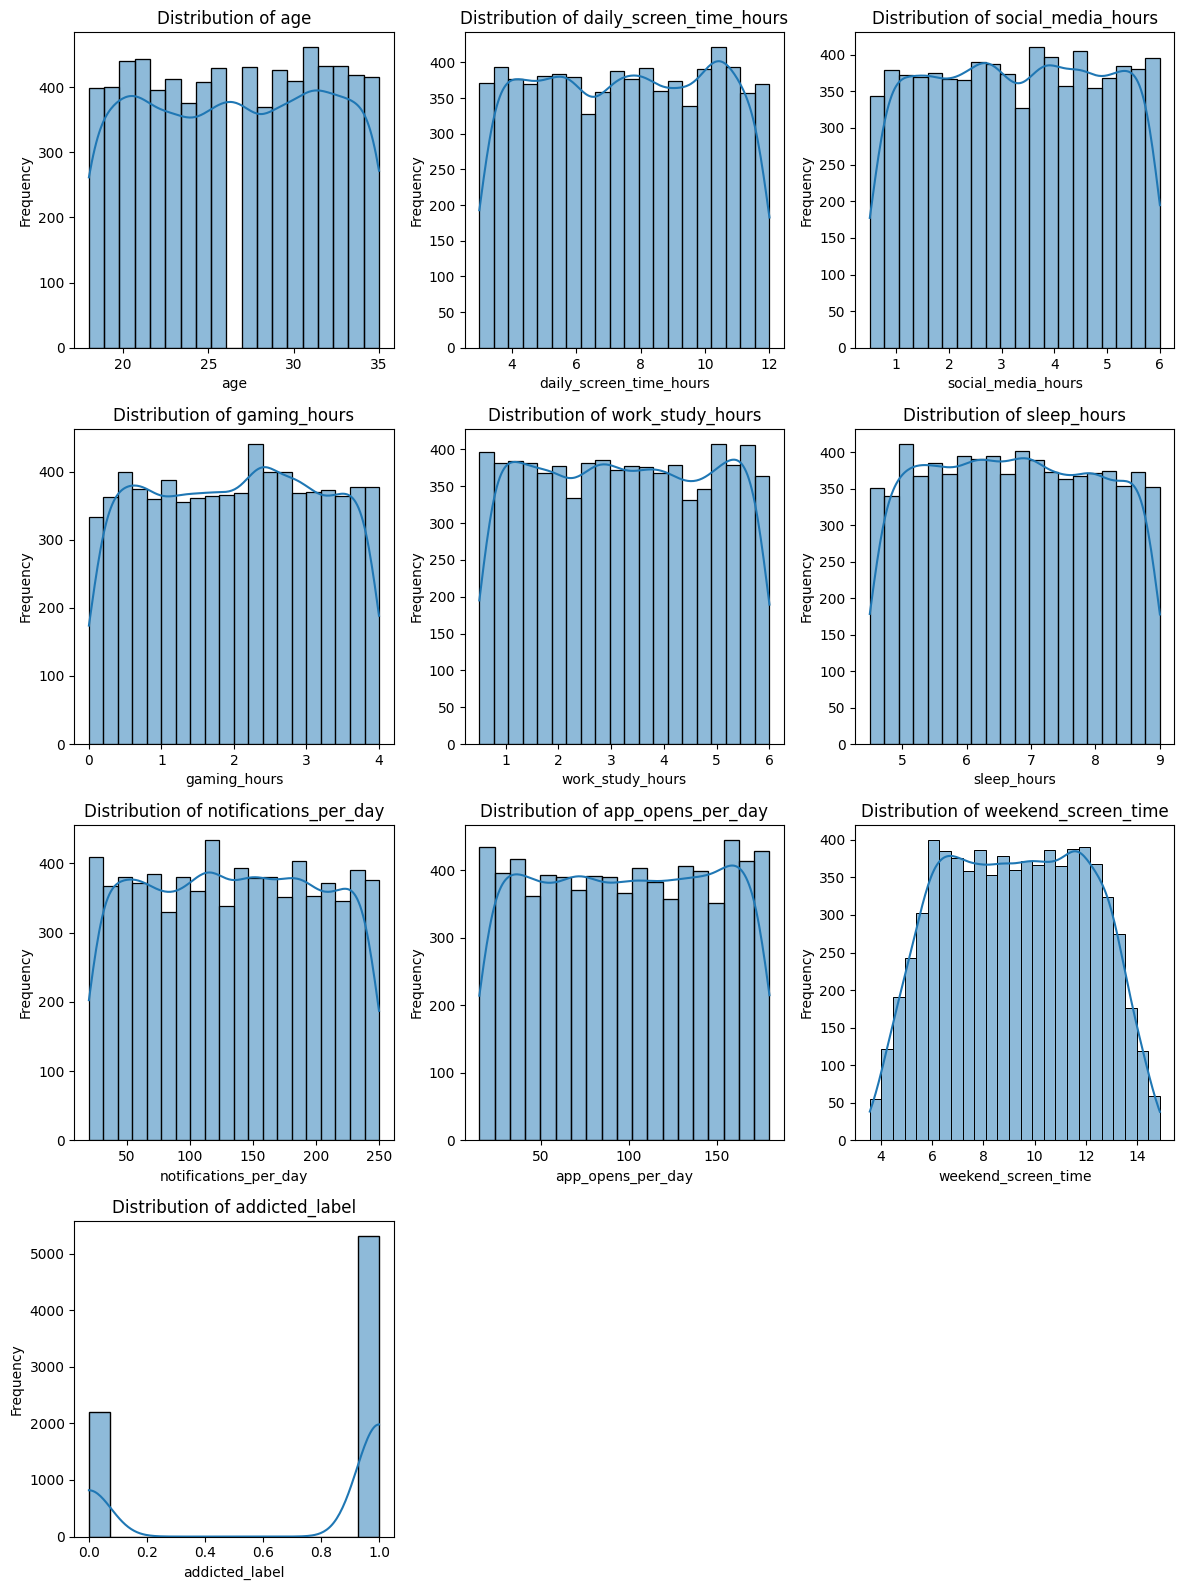

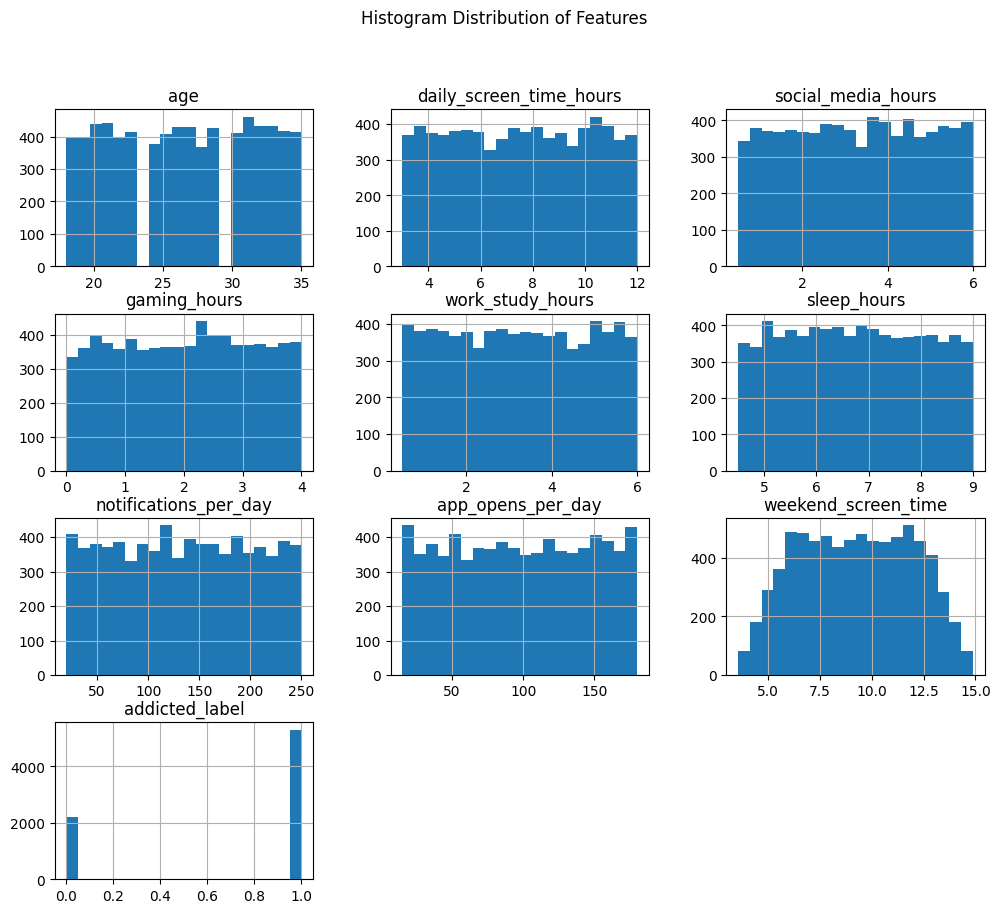

In [26]:
import math

num_cols = len(numeric_cols)
nrows = math.ceil(num_cols / 3)

fig, axes = plt.subplots(nrows, 3, figsize=(12, 4*nrows))

for i, col in enumerate(numeric_cols):
    row = i // 3
    col_idx = i % 3
    ax = axes[row, col_idx]
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

# Hide empty subplots
for i in range(num_cols, nrows * 3):
    row = i // 3
    col_idx = i % 3
    axes[row, col_idx].set_visible(False)

plt.tight_layout()
plt.show()

df.hist(figsize=(12,10), bins=20)

plt.suptitle("Histogram Distribution of Features")
plt.show()

Skewed Data Distribution

In [27]:
for col in numeric_cols:
    skew_value = df[col].skew()
    
    if skew_value > 0:
        dist_type = "Right Skewed (Positive Skew)"
    elif skew_value < 0:
        dist_type = "Left Skewed (Negative Skew)"
    else:
        dist_type = "Normal Distribution"
    
    print(f"{col}: Skewness = {skew_value:.2f} → {dist_type}")

age: Skewness = -0.02 → Left Skewed (Negative Skew)
daily_screen_time_hours: Skewness = -0.01 → Left Skewed (Negative Skew)
social_media_hours: Skewness = -0.01 → Left Skewed (Negative Skew)
gaming_hours: Skewness = -0.02 → Left Skewed (Negative Skew)
work_study_hours: Skewness = 0.01 → Right Skewed (Positive Skew)
sleep_hours: Skewness = 0.02 → Right Skewed (Positive Skew)
notifications_per_day: Skewness = 0.00 → Right Skewed (Positive Skew)
app_opens_per_day: Skewness = -0.01 → Left Skewed (Negative Skew)
weekend_screen_time: Skewness = -0.01 → Left Skewed (Negative Skew)
addicted_label: Skewness = -0.91 → Left Skewed (Negative Skew)


Calculating


a. Mean

In [28]:
df["daily_screen_time_hours"].mean()


np.float64(7.499911999999999)

b. Median

In [29]:
df["daily_screen_time_hours"].median()


np.float64(7.525)

c. Standard Deviation

In [30]:
df["daily_screen_time_hours"].std()


np.float64(2.6091875057537273)

d. Skewness Distribution

In [31]:
df["daily_screen_time_hours"].skew()


np.float64(-0.011366057137983105)

e. Kurtosis

In [32]:
df["daily_screen_time_hours"].kurt()

np.float64(-1.2156949383216928)

Task 5: Automating EDA

Statistical Summary using describe()

In [33]:
print("Statistical Summary")
df.describe(include='all')

Statistical Summary


,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
count,7500,7500,7500.000000,7500,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500,7500,7500,7500.000000
unique,7500,7500,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,2,3,NaN
top,TXN00001,U00001,NaN,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,High,No,Moderate,NaN
freq,1,1,NaN,2553,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2560,3753,3693,NaN
mean,NaN,NaN,26.568800,NaN,7.499912,3.273484,2.014183,3.242420,6.737561,134.257333,97.832400,9.243827,NaN,NaN,NaN,0.707733
std,NaN,NaN,5.197108,NaN,2.609188,1.585342,1.146039,1.600765,1.283605,66.586883,48.423349,2.718281,NaN,NaN,NaN,0.454835
min,NaN,NaN,18.000000,NaN,3.000000,0.500000,0.000000,0.500000,4.500000,20.000000,15.000000,3.580000,NaN,NaN,NaN,0.000000
25%,NaN,NaN,22.000000,NaN,5.220000,1.910000,1.020000,1.850000,5.630000,76.000000,55.000000,6.960000,NaN,NaN,NaN,0.000000
50%,NaN,NaN,27.000000,NaN,7.525000,3.270000,2.040000,3.230000,6.720000,134.000000,98.000000,9.260000,NaN,NaN,NaN,1.000000
75%,NaN,NaN,31.000000,NaN,9.810000,4.630000,2.990000,4.640000,7.840000,191.000000,140.000000,11.540000,NaN,NaN,NaN,1.000000


Dataset Information

In [34]:
print("\n Dataset Information: ")
df.info()


 Dataset Information: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   object 
 1   user_id                  7500 non-null   object 
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   object 
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   object 
 13  academic_work_impact     7500 non-null   object 
 14  

Checking Null Values Using isnull()

In [35]:
print("\n Missing Values Count : ")
print(df.isnull().sum())


 Missing Values Count : 
transaction_id             0
user_id                    0
age                        0
gender                     0
daily_screen_time_hours    0
social_media_hours         0
gaming_hours               0
work_study_hours           0
sleep_hours                0
notifications_per_day      0
app_opens_per_day          0
weekend_screen_time        0
stress_level               0
academic_work_impact       0
addiction_level            0
addicted_label             0
dtype: int64


Crrelation Matrix

In [36]:
print("Correlation Matrix : ")
print(df.corr(numeric_only=True))

Correlation Matrix : 
                              age  daily_screen_time_hours  \
age                      1.000000                 0.012767   
daily_screen_time_hours  0.012767                 1.000000   
social_media_hours       0.000342                 0.010321   
gaming_hours            -0.026107                 0.001140   
work_study_hours        -0.017147                 0.003108   
sleep_hours             -0.007462                 0.019343   
notifications_per_day    0.000387                 0.000811   
app_opens_per_day       -0.002276                 0.024448   
weekend_screen_time      0.015286                 0.964295   
addicted_label           0.004220                 0.577112   

                         social_media_hours  gaming_hours  work_study_hours  \
age                                0.000342     -0.026107         -0.017147   
daily_screen_time_hours            0.010321      0.001140          0.003108   
social_media_hours                 1.000000     -0.000902 

 Task 6: Regression Analysis
 


1. Identify Variables


Dependent Variable (Target)

In [37]:
y = df['daily_screen_time_hours']

Independent Variables

In [38]:
X = df[['social_media_hours']]

Simple Linear Regression

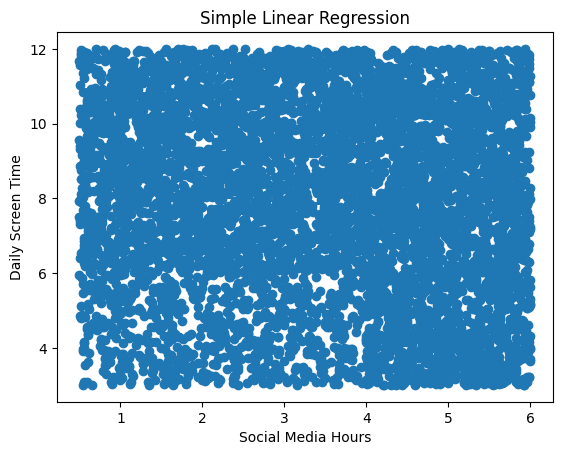

In [39]:

from sklearn.linear_model import LinearRegression


# Load dataset
df = pd.read_csv('Smartphone.csv')

# Handle missing values (important)
df = df.dropna()

# Independent and dependent variables
X = df[['social_media_hours']]
y = df['daily_screen_time_hours']

# Create model
model = LinearRegression()

# Train model
model.fit(X, y)

# Predictions
y_pred = model.predict(X)

# Plot
plt.scatter(X, y)
plt.plot(X, y_pred)
plt.xlabel("Social Media Hours")
plt.ylabel("Daily Screen Time")
plt.title("Simple Linear Regression")
plt.show()

In [40]:
import pandas as pd
from sklearn.linear_model import LinearRegression

df = pd.read_csv("Smartphone.csv")

# Independent variable
X = df[['daily_screen_time_hours']]

# Dependent variable
y = df['addicted_label']

model = LinearRegression()
model.fit(X,y)

print("Coefficient:", model.coef_)
print("Intercept:", model.intercept_)

Coefficient: [0.10060239]
Intercept: -0.046775740482866146


2.  Covariance & Correlation


Covariance

In [41]:
covariance = np.cov(df['social_media_hours'], df['daily_screen_time_hours'])
print("Covariance Matrix:\n", covariance)

Covariance Matrix:
 [[2.51330778 0.042693  ]
 [0.042693   6.80785944]]


Correlation

In [42]:
correlation = df['social_media_hours'].corr(df['daily_screen_time_hours'])
print("Correlation:", correlation)

Correlation: 0.010321160576710469


In [43]:
print(df[['daily_screen_time_hours','addicted_label']].cov())
print(df[['daily_screen_time_hours','addicted_label']].corr())

                         daily_screen_time_hours  addicted_label
daily_screen_time_hours                 6.807859        0.684887
addicted_label                          0.684887        0.206874
                         daily_screen_time_hours  addicted_label
daily_screen_time_hours                 1.000000        0.577112
addicted_label                          0.577112        1.000000


3. Dependent & Independent Variables

Dependent Variable:
addiction_level

Independent Variables:
daily_screen_time_hours, social_media_hours, gaming_hours



In [44]:
X = df[["daily_screen_time_hours","social_media_hours","gaming_hours"]]
y = df["addiction_level"]

Task 7: Supervised Learning – Regression Model

1. Split dataset into:
o Training data
o Testing data

In [45]:
from sklearn.model_selection import train_test_split

X = df[['daily_screen_time_hours','social_media_hours','gaming_hours',
        'work_study_hours','sleep_hours','notifications_per_day',
        'app_opens_per_day','weekend_screen_time']]

y = df['addicted_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

Building Regression Model Using :

Linear Regression Model

In [46]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Overfitting & Underfitting (Explanation)

✔ Overfitting

Model learns too much (including noise)

High accuracy on training, low on testing

✔ Underfitting

Model is too simple

Poor performance on both training & testing

Train Model

In [47]:
y_train_pred = model.predict(X_train)

In [48]:
from sklearn.metrics import mean_squared_error, r2_score

print("Training R2 Score:", r2_score(y_train, y_train_pred))

Training R2 Score: 0.4977477526084244


Test Data

In [49]:
y_test_pred = model.predict(X_test)

print("Testing R2 Score:", r2_score(y_test, y_test_pred))
print("MSE:", mean_squared_error(y_test, y_test_pred))

Testing R2 Score: 0.5091698713501327
MSE: 0.10385180194025355


In [50]:
train_score = model.score(X_train,y_train)
test_score = model.score(X_test,y_test)

print("Training Score:",train_score)
print("Testing Score:",test_score)

Training Score: 0.4977477526084244
Testing Score: 0.5091698713501327


Models Required

(i) Simple Linear Regression Model

In [51]:
X_simple = df[['social_media_hours']]
y = df['daily_screen_time_hours']

X_train, X_test, y_train, y_test = train_test_split(X_simple, y, test_size=0.2)

model_simple = LinearRegression()
model_simple.fit(X_train, y_train)

print("Simple Model Score:", model_simple.score(X_test, y_test))

Simple Model Score: 3.616251440052842e-05


 (ii) Multiple Linear Regression Model


In [52]:
X_multi = df[['social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours']]
y = df['daily_screen_time_hours']

X_train, X_test, y_train, y_test = train_test_split(X_multi, y, test_size=0.2)

model_multi = LinearRegression()
model_multi.fit(X_train, y_train)

print("Multiple Model Score:", model_multi.score(X_test, y_test))

Multiple Model Score: 0.0002460308477952866


(iii) Logistic Regression Model (Classification)

In [53]:
from sklearn.linear_model import LogisticRegression

# Convert categorical if needed
df['gender'] = df['gender'].astype('category').cat.codes

X_log = df[['daily_screen_time_hours', 'social_media_hours', 'gaming_hours']]
y_log = df['addicted_label']

X_train, X_test, y_train, y_test = train_test_split(X_log, y_log, test_size=0.2)

log_model = LogisticRegression(max_iter=200)
log_model.fit(X_train, y_train)

# Accuracy
print("Logistic Regression Accuracy:", log_model.score(X_test, y_test))

Logistic Regression Accuracy: 0.8826666666666667


Task 9: Overfitting and Underfitting Analysis

Overfitting

Overfitting occurs when a model:

Learns training data too well
Captures noise instead of patterns
Performs very well on training data
Performs poorly on testing data

Example:

Training Accuracy = 95%
Testing Accuracy = 60%

This indicates overfitting.

Underfitting

Underfitting occurs when a model:

Is too simple
Cannot capture patterns in data
Performs poorly on both training and testing data

Example:

Training Accuracy = 60%
Testing Accuracy = 58%

Training vs Testing Error Comparison

In [54]:
train_score = model.score(X_train,y_train)
test_score = model.score(X_test,y_test)

print("Training Score:",train_score)
print("Testing Score:",test_score)

ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- app_opens_per_day
- notifications_per_day
- sleep_hours
- weekend_screen_time
- work_study_hours


Task 10: Classification Task

Step 1: Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

Step 2: Data Preprocessing

In [ ]:
# Handle missing values
df = df.ffill()

# Convert categorical to numerical
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

Step 3: Define X and y

In [ ]:
X = df[['daily_screen_time_hours','social_media_hours','gaming_hours',
        'work_study_hours','sleep_hours','notifications_per_day',
        'app_opens_per_day','weekend_screen_time']]

y = df['addicted_label']

 Step 4: Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Step 5: Build Classification Model

In [ ]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

Step 6: Evaluation

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0

Confusion Matrix:
 [[ 456    0]
 [   0 1044]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       456
           1       1.00      1.00      1.00      1044

    accuracy                           1.00      1500
   macro avg       1.00      1.00      1.00      1500
weighted avg       1.00      1.00      1.00      1500



Confusion Matrix

In [ ]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[ 456    0]
 [   0 1044]]


Task 11: Model Evaluation (Regression + Comparison)


Step 1 : Regression Model

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Define target
y_reg = df['daily_screen_time_hours']
X_reg = df.drop(['daily_screen_time_hours', 'addicted_label'], axis=1)

# Split
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Model
reg_model = LinearRegression()
reg_model.fit(X_train_r, y_train_r)

y_pred_r = reg_model.predict(X_test_r)

Step 2 : Evaluation Metrics

In [ ]:
mse = mean_squared_error(y_test_r, y_pred_r)
mae = mean_absolute_error(y_test_r, y_pred_r)
r2 = r2_score(y_test_r, y_pred_r)

print("MSE:", mse)
print("MAE:", mae)
print("R2 Score:", r2)

MSE: 0.5019008405978945
MAE: 0.6122092788454565
R2 Score: 0.9284417344141999


Step 3: Interpretation

MSE: Lower = better (penalizes large errors)

MAE: Average error

R² Score:

1 → perfect model

0 → poor model

Step 4: Comparison

| Type           | Output           | Metric       |
| -------------- | ---------------- | ------------ |
| Classification | Category (0/1)   | Accuracy     |
| Regression     | Continuous value | MSE, MAE, R² |


Train Model & Save 

In [ ]:
import pickle

# Save model
pickle.dump(model, open('model.pkl', 'wb'))